Возводим признак в квадрат и в куб для того, чтобы модель могла обучаться на сложных извилистых данных, оставаясь при этом математически простой линейной моделью. Этот прием называется **полиномиальной регрессией** (Polynomial Regression), например когда вектор целевых значений Y - синусоида.

In [ ]:
  Степени: [1, x]            Степени: [1, x, x²]          Степени: [1, x, x², x³]
   (Просто прямая)            (Один изгиб / Парабола)      (Два изгиба / Кубическая)
        Y                          Y                           Y
        │  /                       │   .---.                   │    .--.  
        │ /                        │  /     \                  │   /    \ 
        │/                         │ /       \                 │  /      \ /
   ─────┼────── X             ─────┼───────── X           ─────┼─────────┼─── X
       /│                          │                           │        /
      / │                          │                           │       /


Главный трюк: Модель остается ЛИНЕЙНОЙ!

1. Для алгоритма обучения (МНК) абсолютно не важно, откуда взялись числа во 2-м и 3-м столбцах матрицы \(X\). Он не знает, что `0.64` — это квадрат от `-0.8`. Для него это просто «Признак №2» и «Признак №3».
2. Поскольку сами веса \(w\) входят в формулу линейно (они никуда не возводятся и не прячутся в синусы), мы можем использовать **всё ту же простую и сверхбыструю формулу МНК**: `np.linalg.inv(X.T @ X) @ X.T @ Y`.

---

### Методы NumPy
- **np.column_stack**  - берет 4 плоских массива, превращает в колонки и делает матрицу

- **np.ones_like** - генерирует [1.0, 1.0, 1.0...], на основе len(x) и type x, для (bias/w0)

- **x ** 2**  - возводит все значение массива x в квадрат

In [ ]:
X = np.column_stack([np.ones_like(x), x, x**2, x**3])

In [ ]:
    Столбец 1         Столбец 2        Столбец 3        Столбец 4
 (np.ones_like)          (x)            (x**2)           (x**3)

  ┌   1.0   ┐      ┌  -1.0  ┐      ┌   1.0   ┐      ┌  -1.0   ┐
  │   1.0   │      │  -0.9  │      │   0.81  │      │  -0.729 │
  │   1.0   │  +   │  -0.8  │  +   │   0.64  │  +   │  -0.512 │
  │   ...   │      │   ...  │      │   ...   │      │   ...   │
  └   1.0   ┘      └   0.9  ┘      └   0.81  ┘      └   0.729 ┘
                               ↓
                        np.column_stack
                               ↓
                      Итоговая матрица X:
                     ┌                             ┐
                     │ 1.0   -1.0    1.0    -1.0   │  <- Объект 1 (x = -1.0)
                     │ 1.0   -0.9    0.81   -0.729 │  <- Объект 2 (x = -0.9)
                     │ 1.0   -0.8    0.64   -0.512 │  <- Объект 3 (x = -0.8)
                     │ ...    ...     ...     ...  │
                     │ 1.0    0.9    0.81    0.729 │  <- Объект 20 (x = 0.9)
                     └                             ┘


- **@** - перемножение матриц

- **X.T** - транспонирование матрицы (3х2 -> 2x3), не копирует данные в RAM, а создает View

- **np.linalg.inv** - нахождение обратной матрицы (** -1), только для *квадратной* матрицы и *не вырожденной* матрицы.

Пример проблемы вырожденной матрицы: сбор логов, в матрице признаков есть столбец **Размер файла в Кб** и столбец **Размер файла в Мб**. Второй столбец — это просто первый, деленный на 1024. Они линейно зависимы.

In [ ]:
w = np.linalg.inv(X.T @ X) @ X.T @ Y # Метод наименьших квадратов (МНК), для поиска идеальных весов

- **np.arange** - аналог range, возвращает nparray

- **np.vstack**  - складывает массивы в массив [[], []]

- **np.mean** - вычисляет среднее арифметическое элементов массива


In [ ]:
ranged = np.arange([-1.0, 1.0, 0.1])
#-----------------------------------
A = np.array([10, 20, 30])
B = np.array([40, 50, 60])

# [[10, 20, 30], [40, 50, 60]]
matrix = np.vstack([A, B])
#-----------------------------------
mean_cols = np.mean(matrix, axis=0) # среднее по 1 оси, [(10 + 40) / 2, (20 + 50) / 2]
mean_rows = np.mean(matrix, axis=1) # среднее по 2 оси [(10 + 20 + 30) / 3, 40 + 50 + 60 / 3]
mean = np.mean(matrix) # среднее по всем осям [10+20+30+40+50+60 / 6]


---

## 1.5 Оценка степени переобучения модели

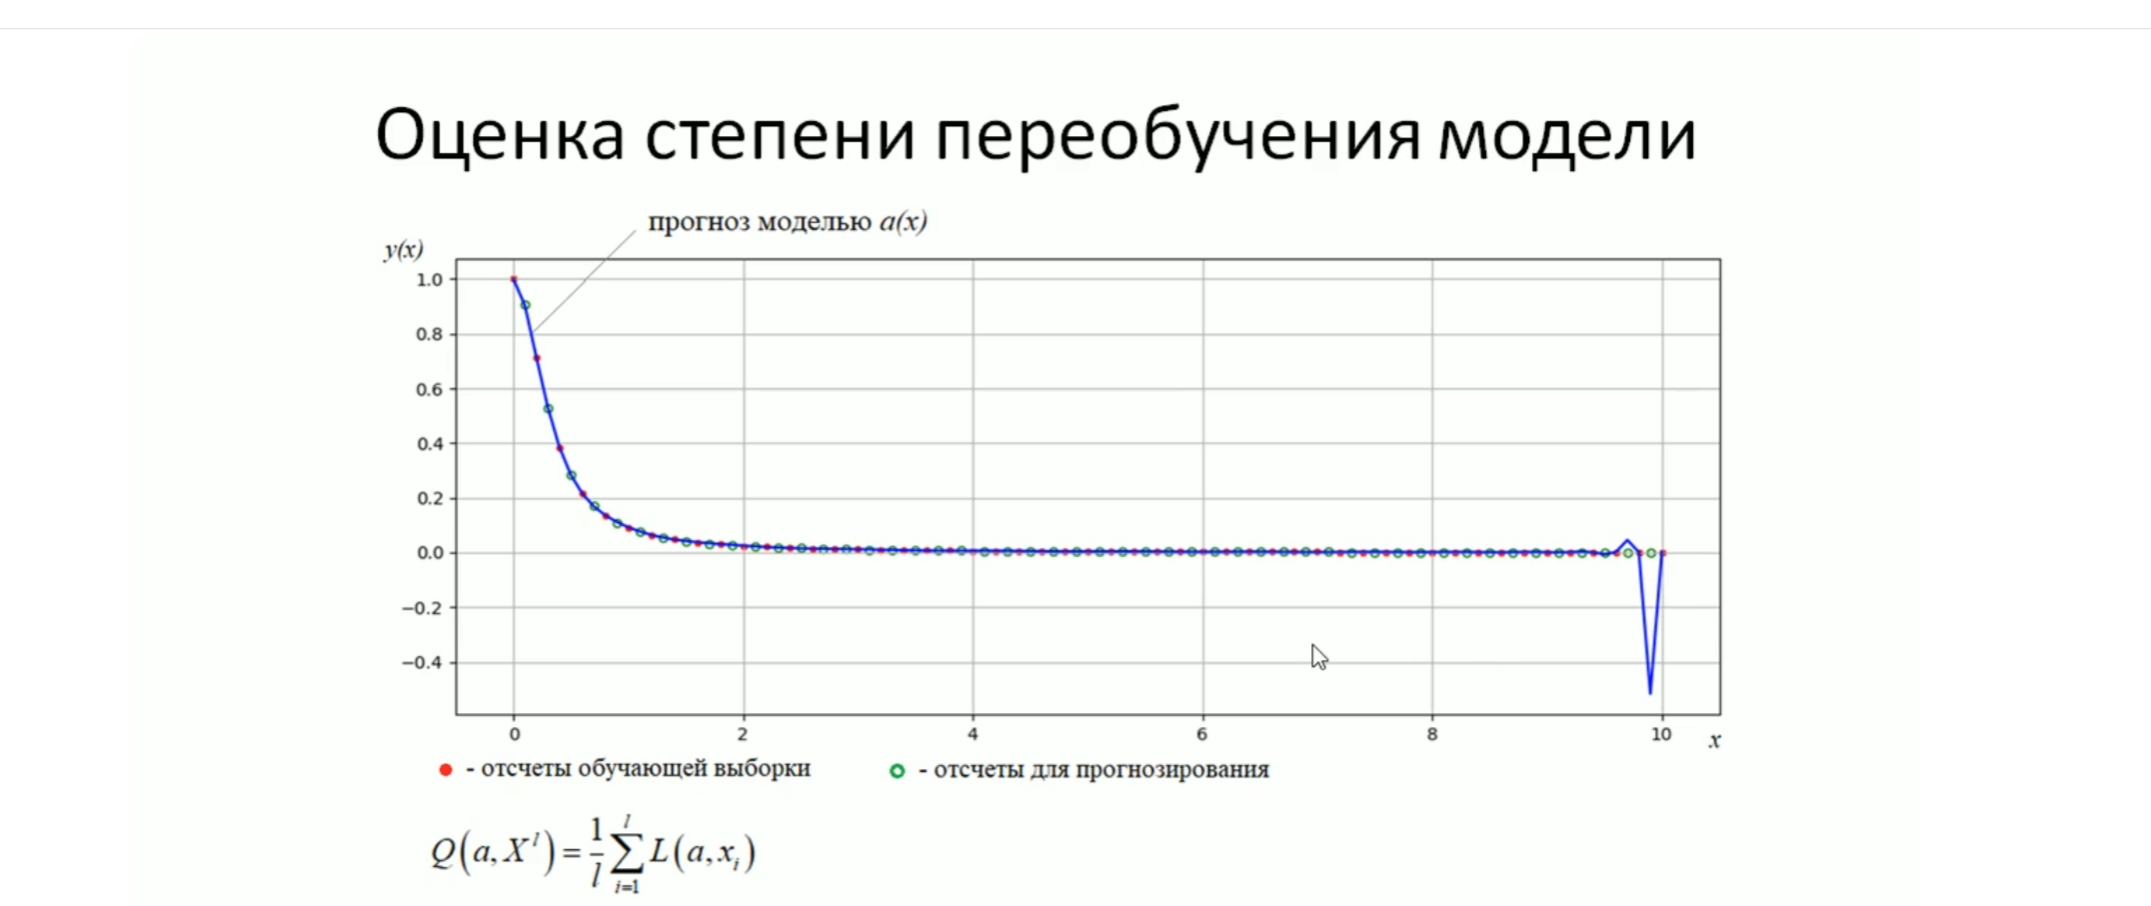

1. Средние потери на обучающей выборке - `величина эмпирического риска`

In [ ]:
import numpy as np

np.random.seed(0)
x = np.arange(-1.0, 1.0, 0.1) # аргумент [-1; 1] с шагом 0,1

model_a = lambda xx, ww: (ww[0] + ww[1] * xx) # модель
loss = lambda ax, y: (ax - y) ** 2
Y = -5.2 + 0.7 * x + np.random.normal(0, 0.1, len(x)) # вектор целевых значений

X = np.vstack([np.ones(len(x)), x]).T
w = np.linalg.inv(X.T @ X) @ X.T @ Y
predict = model_a(x,w)
Q = np.mean(loss(predict, Y)) # величина эмпирического риска

2. `Оценка по отложенной выборке` (hold-out)

Размеченные данные = 70% обучающие + 30% тестовые  
  
Бывает достаточным при большом обьеме выборки (50000+)

Получаем Q1 - для обучающей и Q2 - для тестовой и если Q1 ~ Q2 - то модель рабочая  

Минусы: на практике может показать себя плохо

3. `Скользящий контроль` (leave-one-out)

Алгоритм метода LOO

1. Выберите наблюдение из выборки, которое будет использоваться для оценки качества модели.
2. Обучите модель на всех данных, кроме выбранного наблюдения.
3. Используйте выбранное наблюдение для оценки качества модели.
4. Повторите шаги 1-3 для каждого наблюдения в выборке.

Преимущества +

- **Точная оценка качества**: Метод LOO позволяет оценить качество модели на всех доступных данных, что дает более точную оценку качества модели.
- **Нет необходимости в разделении данных**: Метод LOO не требует разделения данных на обучающую и тестовую выборки, что может быть полезно для небольших выборок.
- **Можно использовать для оценки качества моделей**: Метод LOO можно использовать для оценки качества моделей, обученных на небольших выборках.

Недостатки -

- **Высокая вычислительная сложность**: Метод LOO требует обучения модели на всех данных, кроме одного наблюдения, что может быть очень затратно для больших выборок.
- **Не подходит для больших выборок**: Метод LOO не подходит для больших выборок, поскольку требует обучения модели на всех данных, кроме одного наблюдения.

4. `Кросс-валидация` (cross-validation, k-fold)

Метод, похож на LOO, разбивает выборки на k равных частей и обучает модель по комбинациям из k-1 фолдов (частей) с проверкой на оставшейся k-й части. Тяжелый для большого объема выборки.

Получаем на выходе модели: a1(x), a2(x), a3(x), ..., ak(x), из которой можем выбрать лучшую разными способами:  

1. **Усреднение** — когда мы хотим использовать предсказательную силу всех \(k\) моделей на инференсе, объединив их в комитет (ансамбль).  

2. **Выбор лучшей** — когда мы смотрим на метрики каждого фолда и сохраняем в качестве финального продакшен-артефакта тот единственный инстанс, который показал минимальный лосс на своей валидационной части.  

3. **Дообучение по цепочке** — когда вместо создания k разных файлов весов, одна модель последовательно обучается на каждом батче-разбиении, собирая знания со всей выборки.

---

## 1.6 Классификация входных наблюдений

Распознование лиц, отпечатков, радужки глаза - `построение разделяющей гиперплоскости` в определенном признаковом пространстве.

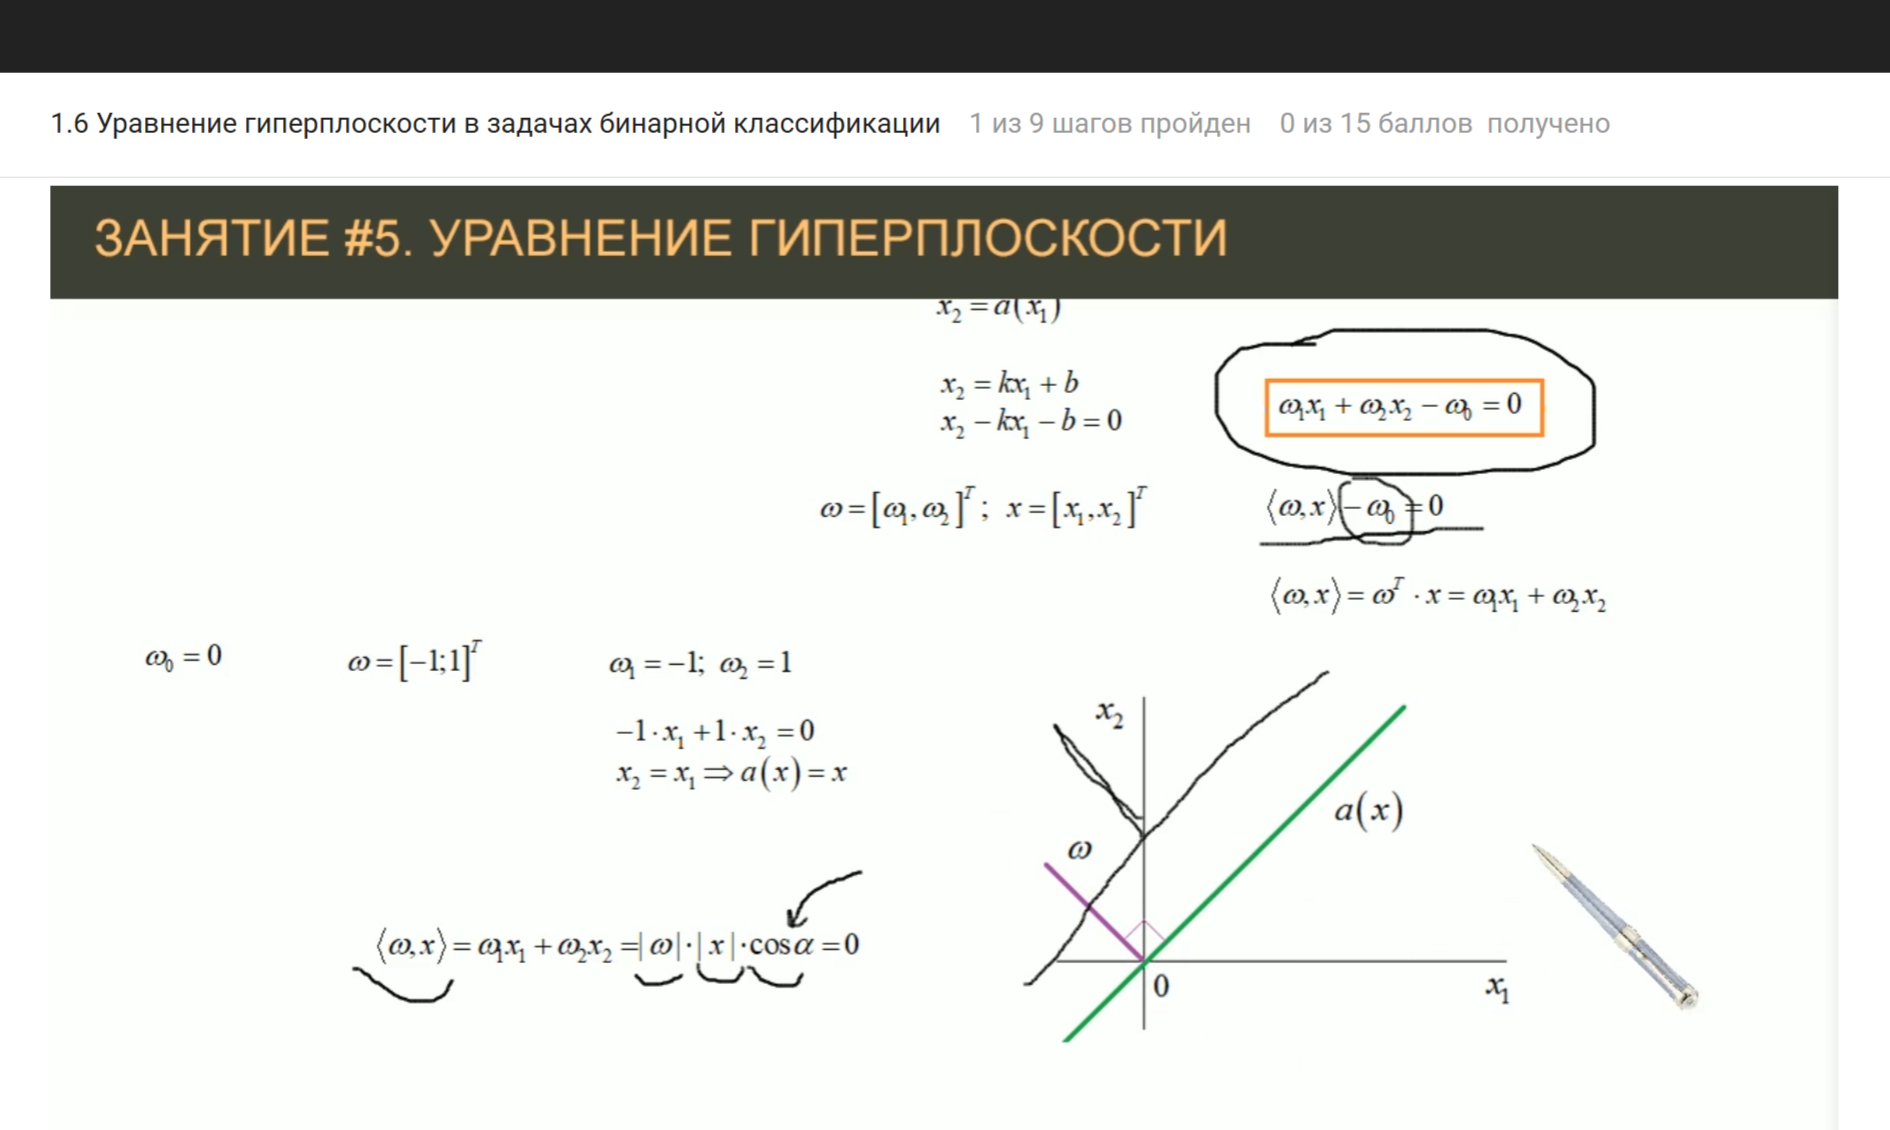

Вектор w ортоганален разделяющей прямой a(x) -> cos=0, важно при решение задач классификации входных данных с помощью линейных моделей.

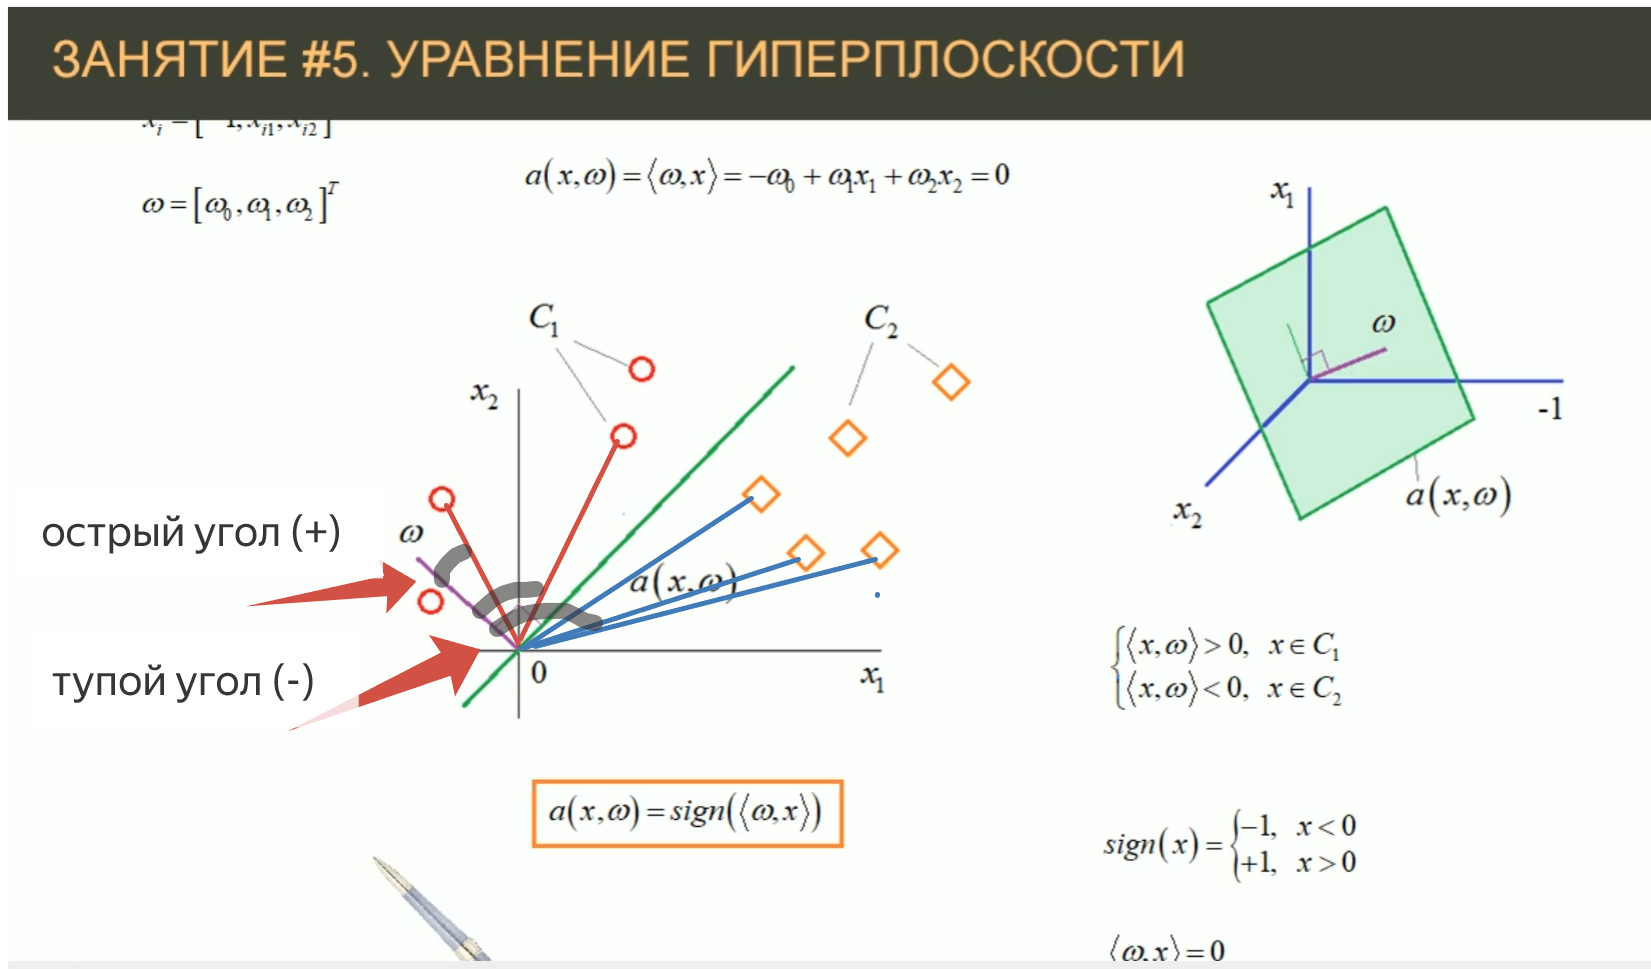

Таким образом можно задавать разделяющую прямую или разделяющую гиперплоскость с помощью вектора параметров w, который всегда направлен под 90град к разделяющей, мы можем выполнять задачу классификации по правилу a(x, w) = sign({w, x}); где {w, x} - скалярное произведение векторов.

---

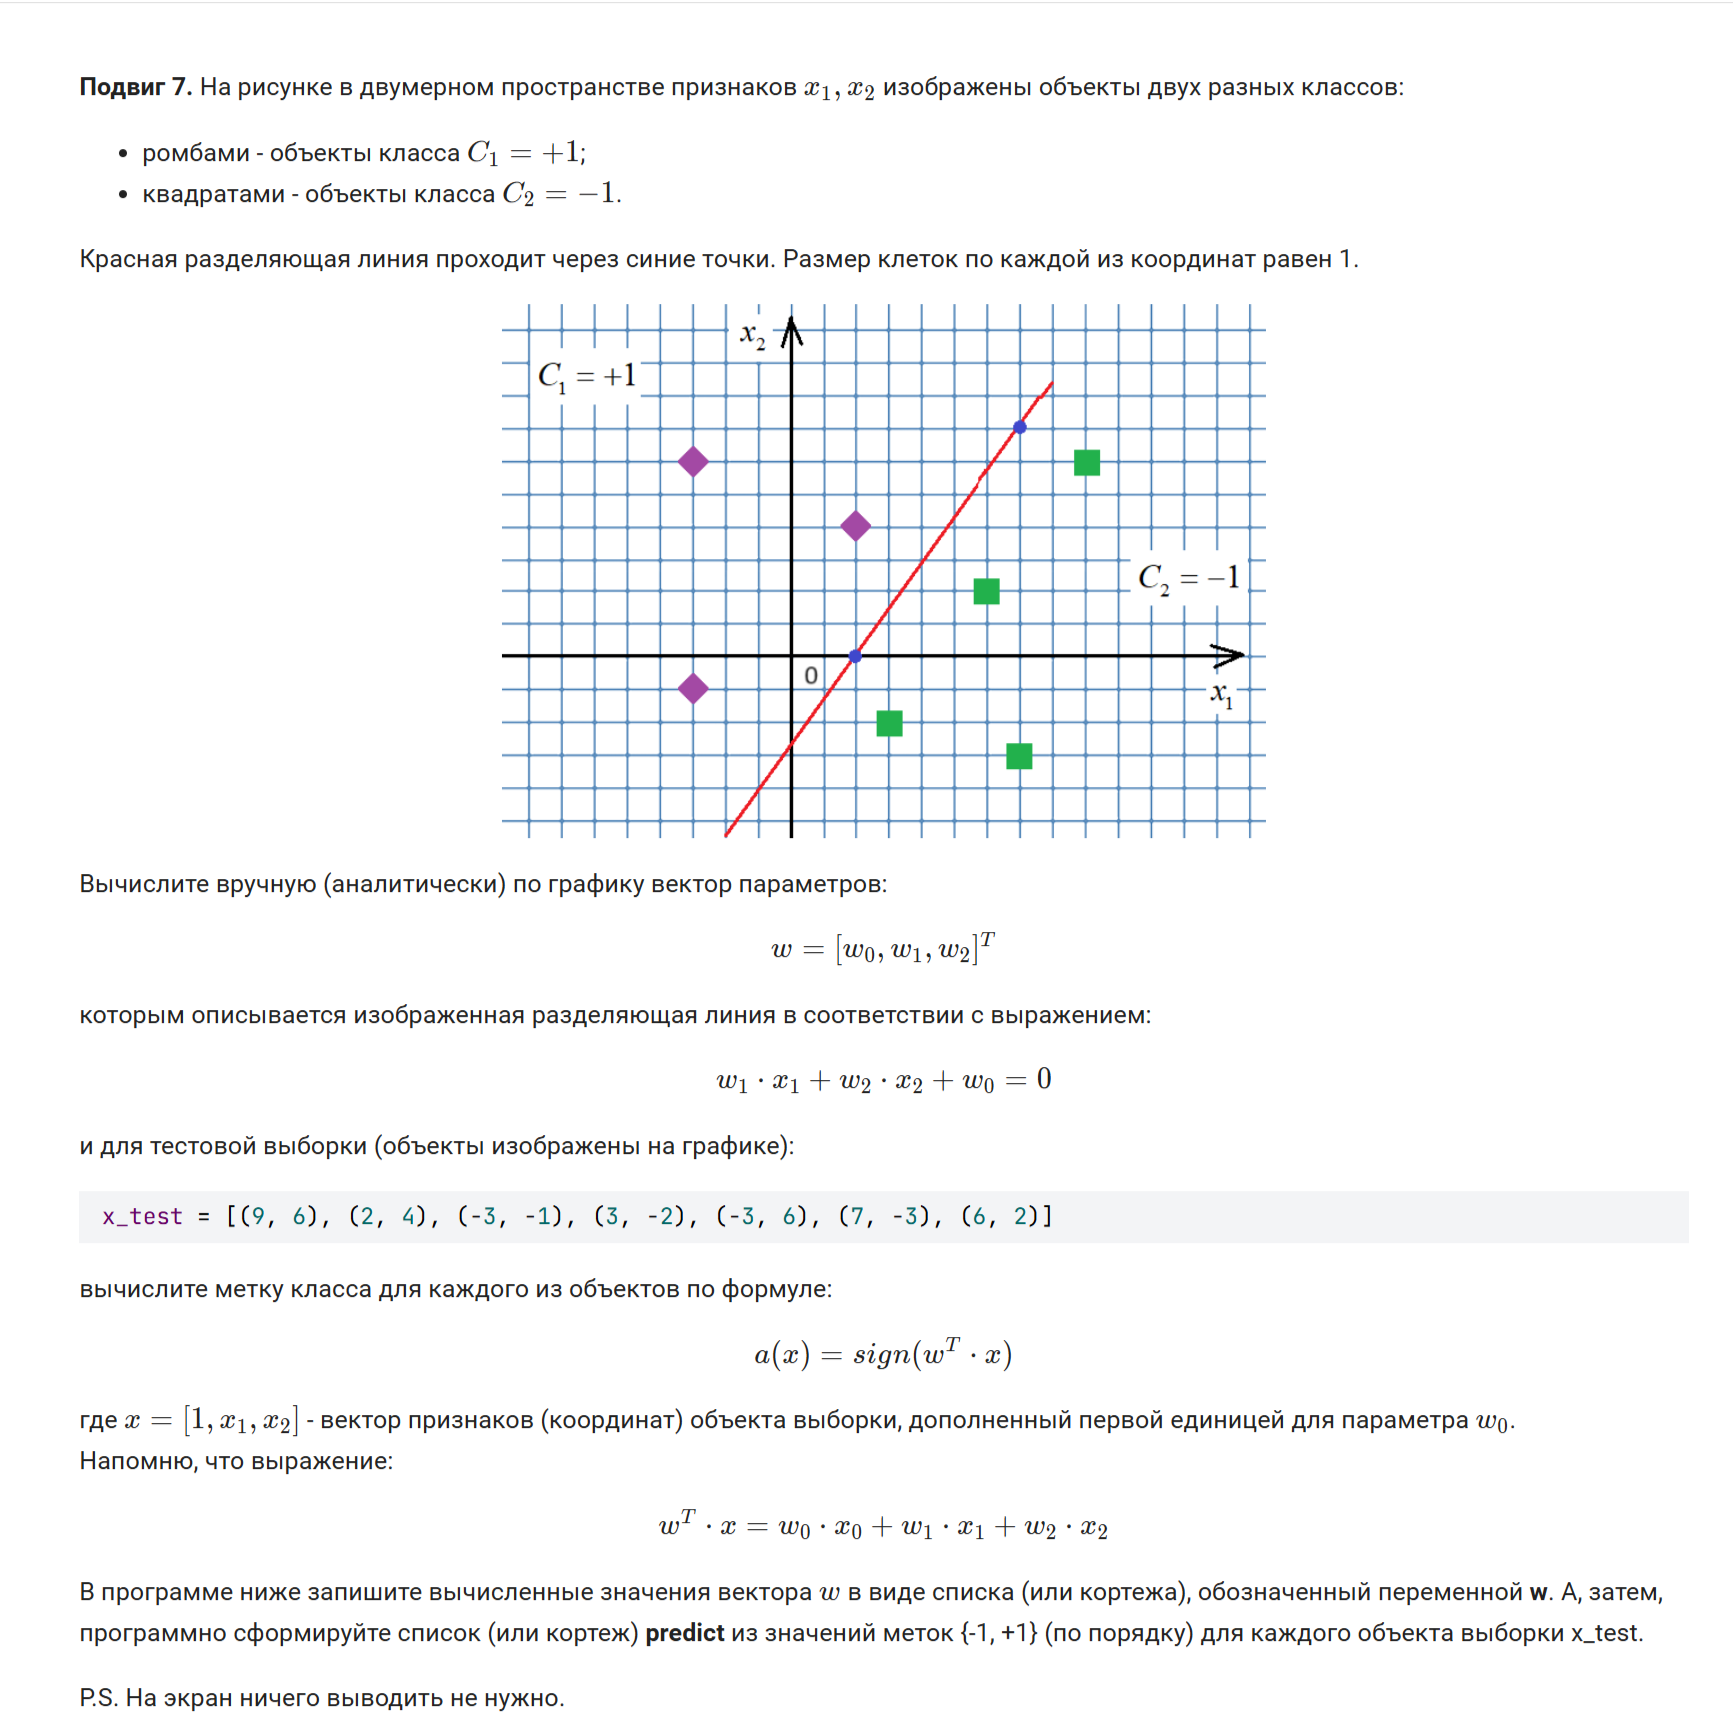

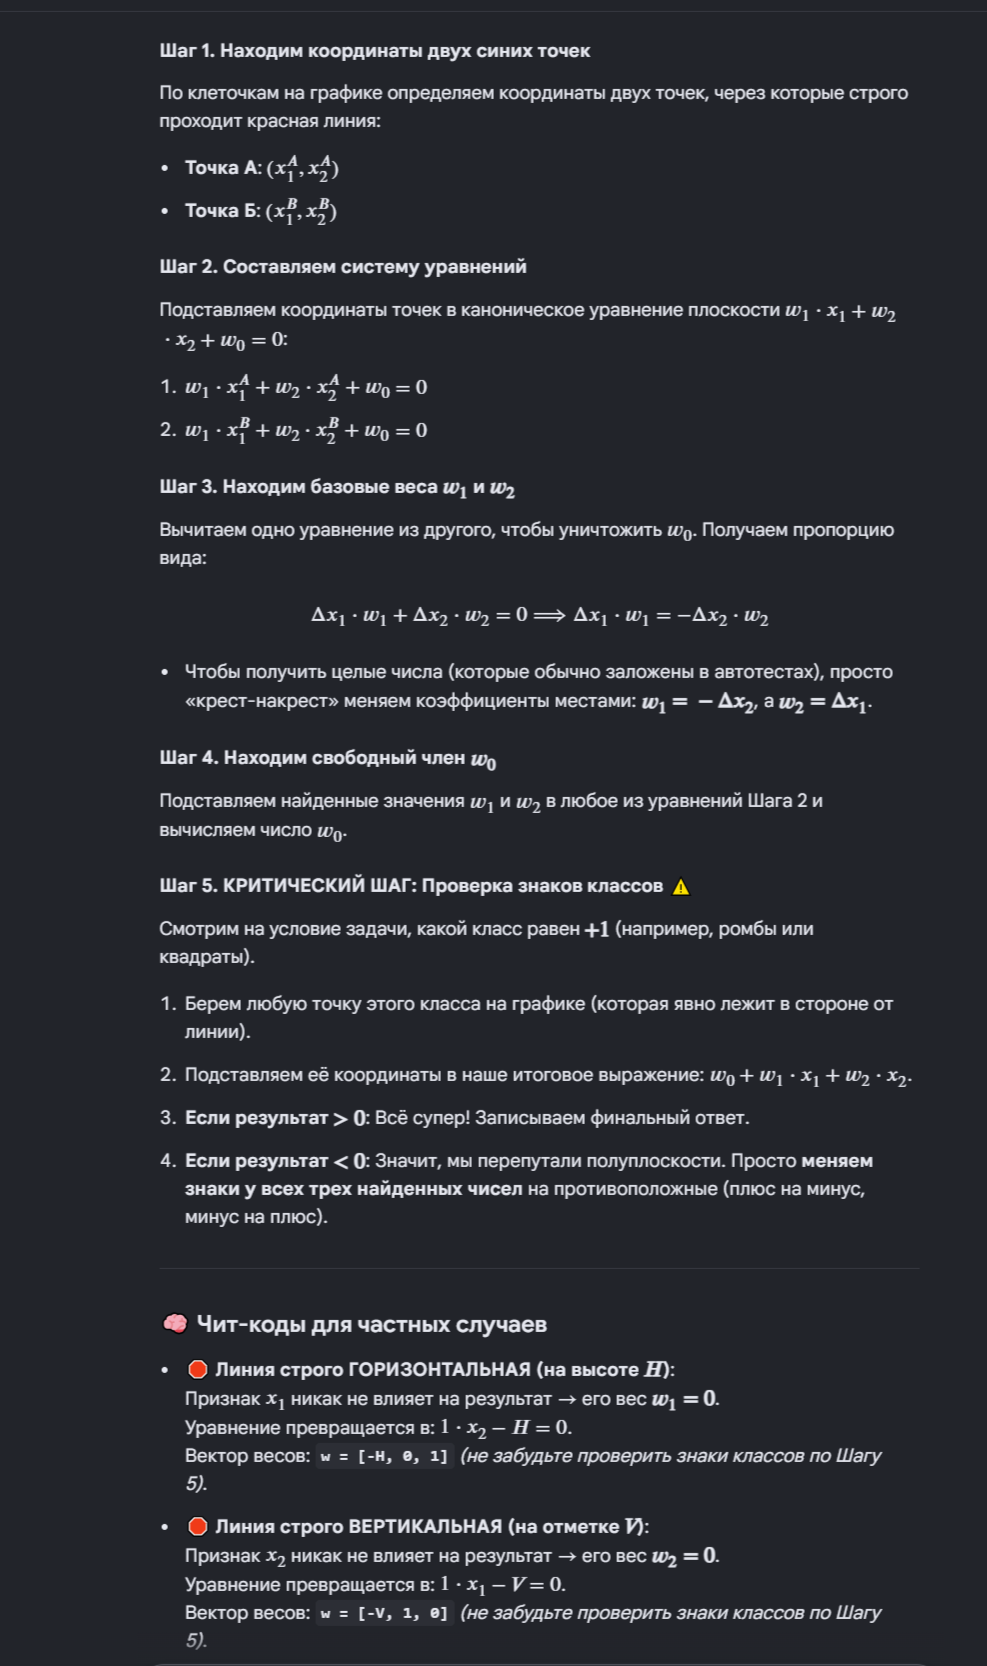

In [ ]:
import numpy as np

x_test = [(9, 6), (2, 4), (-3, -1), (3, -2), (-3, 6), (7, -3), (6, 2)]

w = [14, -7, 5]
predict = [1 if (w + w*pt + w*pt) >= 0 else -1 for pt in x_test]

---